# Debug: Low Cell Yield in Suite2p + Cellpose

This notebook analyzes why cell detection yields are low and systematically explores parameter settings to improve detection.

## Dataset
- Path: `\\rbo-s1\S1_DATA\lbm\christian\2025-11-21\results\plane01_stitched`

## Key Findings from Initial Analysis

| Parameter | Current Value | Problem | Recommended |
|-----------|---------------|---------|-------------|
| `spatial_hp_cp` | **3.0** | HP filter sigma=18px removes cell-scale structure | **0** or **2.0** |
| `cellprob_threshold` | -6.0 | None | -6.0 to 0.0 |
| `diameter` | 6 | May be too large for this data | Check actual cell sizes |

### Grid Search Results Summary
- **Best config**: `spatial_hp_cp=2.0`, `cellprob=-6`, `flow=0.0` → **287 accepted cells**
- `spatial_hp_cp=2.0` consistently outperforms `spatial_hp_cp=0.5`
- Smaller diameter (~2 pixels in folder name, fitted to ~6px) works better than larger

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, label
from pathlib import Path
import time

from cellpose import models, core, transforms
from cellpose.plot import mask_rgb

print(f"GPU available: {core.use_gpu()}")

GPU available: True


## Configuration

In [ ]:
S2P_DIR = Path(r"//rbo-s1/S1_DATA/lbm/christian/2025-11-21/results/grid_search")
for directory in S2P_DIR.iterdir():
    if directory.is_dir():
        for x in directory.iterdir():
            if x.suffix == ".npy":
                print(x.name)
    print("------")

F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy
stat.npy
------
F.npy
Fneu.npy
iscell.npy
ops.npy
spks.npy

: 

In [2]:
# === EDIT THIS: Path to your Suite2p results ===
S2P_DIR = Path(r"//rbo-s1/S1_DATA/lbm/christian/2025-11-21/results/plane01_stitched")
OUTPUT_DIR = S2P_DIR.parent / "debug_low_yield"
OUTPUT_DIR.mkdir(exist_ok=True)

# Load ops
ops = np.load(S2P_DIR / "ops.npy", allow_pickle=True).item()

print("=== Current Suite2p Parameters ===")
params_of_interest = ['anatomical_only', 'diameter', 'cellprob_threshold',
                      'flow_threshold', 'spatial_hp_cp', 'threshold_scaling']
for p in params_of_interest:
    print(f"  {p}: {ops.get(p, 'N/A')}")

print(f"\nImage size: {ops['Ly']} x {ops['Lx']}")
print(f"Frames: {ops['nframes']}")

=== Current Suite2p Parameters ===
  anatomical_only: 4
  diameter: 6
  cellprob_threshold: -6.0
  flow_threshold: 0.0
  spatial_hp_cp: 3.0
  threshold_scaling: 1.0

Image size: 772 x 735
Frames: 300


## Load Images from ops.npy

In [3]:
# Extract images
mean_img = ops['meanImg'].astype(np.float32)
mean_img_e = ops['meanImgE'].astype(np.float32)
max_proj = ops['max_proj'].astype(np.float32)
vcorr = ops.get('Vcorr', np.zeros_like(mean_img)).astype(np.float32)

# Current detection results
stat = np.load(S2P_DIR / "stat.npy", allow_pickle=True)
iscell = np.load(S2P_DIR / "iscell.npy", allow_pickle=True)

n_total = len(stat)
n_cells = int(np.sum(iscell[:, 0]))
print(f"Current detection: {n_cells} cells / {n_total} total ROIs")

# Reconstruct current mask
current_mask = np.zeros((ops['Ly'], ops['Lx']), dtype=np.uint16)
for i, s in enumerate(stat):
    if iscell[i, 0]:
        ypix, xpix = s['ypix'], s['xpix']
        valid = (ypix >= 0) & (ypix < current_mask.shape[0]) & (xpix >= 0) & (xpix < current_mask.shape[1])
        current_mask[ypix[valid], xpix[valid]] = i + 1

Current detection: 451 cells / 451 total ROIs


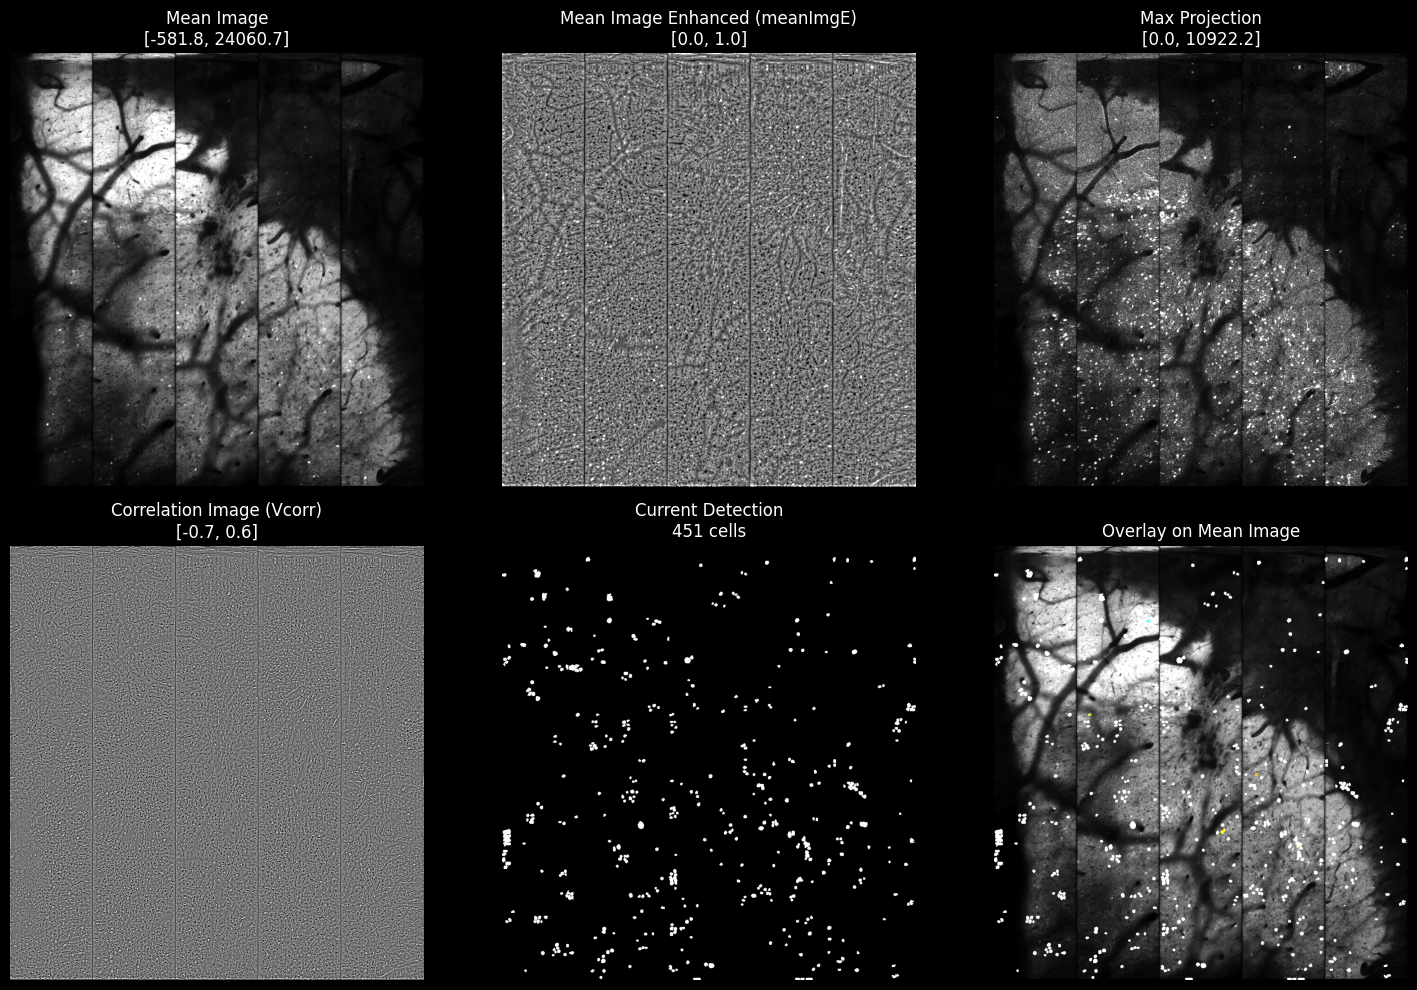

In [4]:
# Visualize all available images
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

def imshow_percentile(ax, img, title, cmap='gray', pmin=1, pmax=99):
    vmin, vmax = np.percentile(img, [pmin, pmax])
    ax.imshow(img, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(f"{title}\n[{img.min():.1f}, {img.max():.1f}]")
    ax.axis('off')

imshow_percentile(axes[0, 0], mean_img, 'Mean Image')
imshow_percentile(axes[0, 1], mean_img_e, 'Mean Image Enhanced (meanImgE)')
imshow_percentile(axes[0, 2], max_proj, 'Max Projection')
imshow_percentile(axes[1, 0], vcorr, 'Correlation Image (Vcorr)')

# Current masks
axes[1, 1].imshow(current_mask > 0, cmap='gray')
axes[1, 1].set_title(f'Current Detection\n{n_cells} cells')
axes[1, 1].axis('off')

# Overlay
def mask_overlay(img, mask, alpha=0.5):
    img_norm = (img - np.percentile(img, 1)) / (np.percentile(img, 99) - np.percentile(img, 1) + 1e-8)
    img_norm = np.clip(img_norm, 0, 1)
    rgb = np.stack([img_norm] * 3, axis=-1)
    if mask.max() > 0:
        colors = mask_rgb(mask)
        mask_px = mask > 0
        rgb[mask_px] = (1 - alpha) * rgb[mask_px] + alpha * colors[mask_px]
    return np.clip(rgb, 0, 1)

axes[1, 2].imshow(mask_overlay(mean_img, current_mask))
axes[1, 2].set_title(f'Overlay on Mean Image')
axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'current_state.png', dpi=150)
plt.show()

## Problem 1: Spatial High-Pass Filter is Too Aggressive

The current `spatial_hp_cp=3.0` creates a Gaussian filter with `sigma = diameter × spatial_hp_cp = 6 × 3.0 = 18 pixels`.

This is **3× the cell diameter**, meaning the HP filter removes structure at the cell scale.

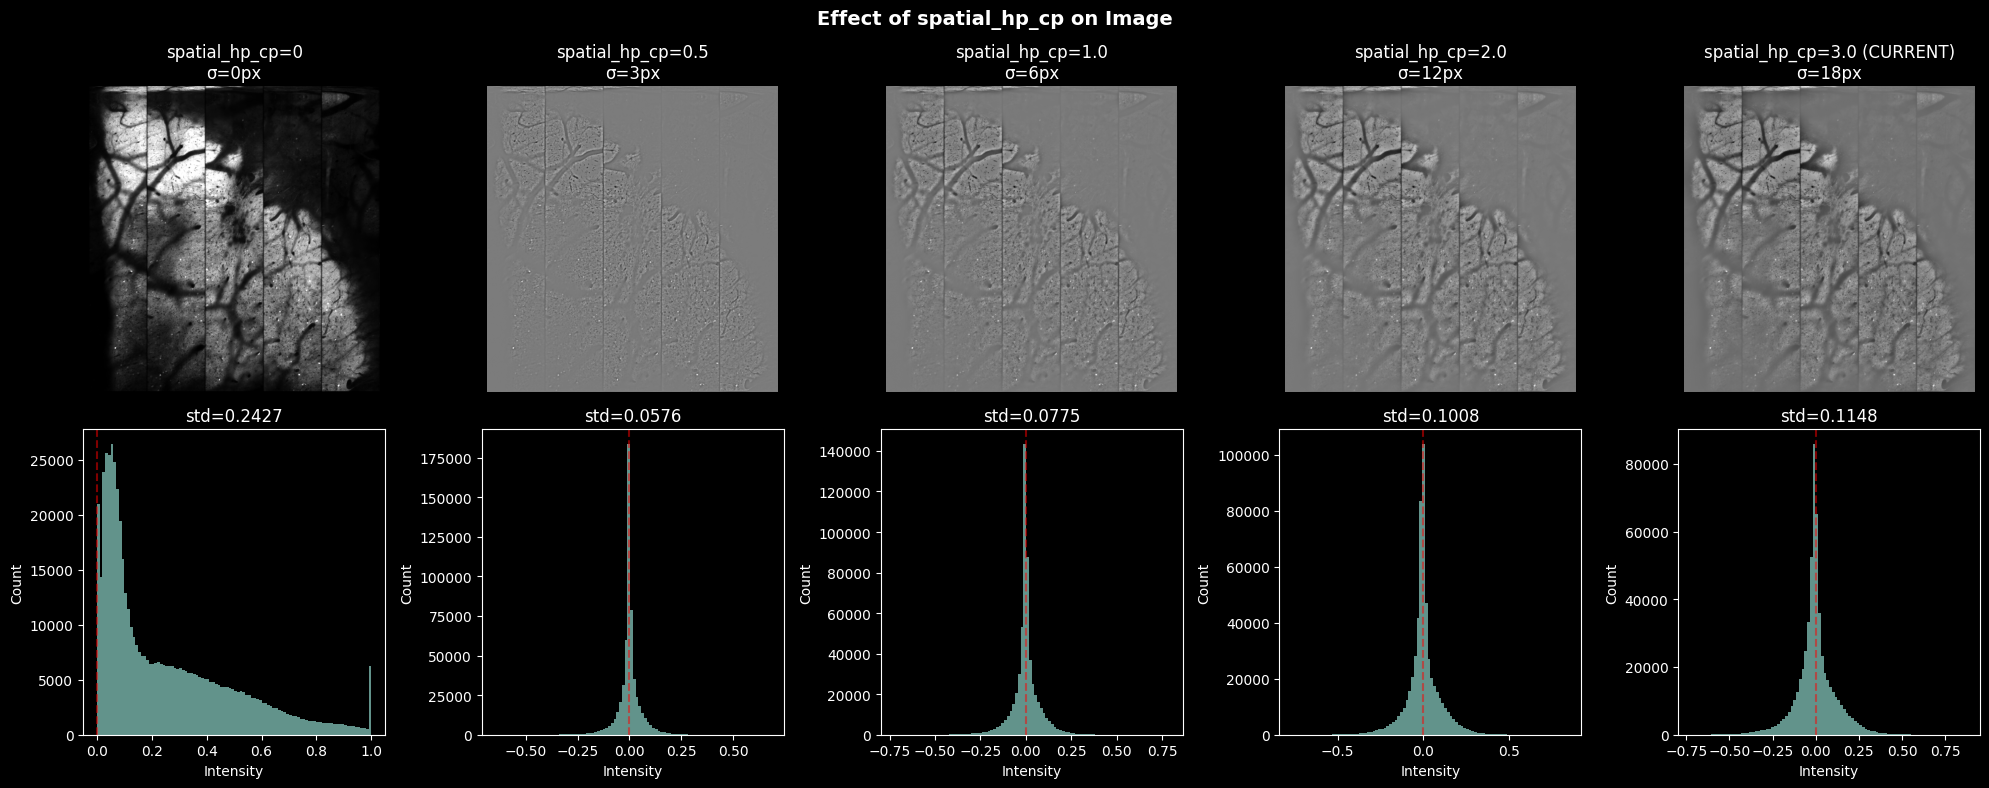

In [5]:
def normalize99(img):
    """Normalize to 1st and 99th percentiles."""
    p1, p99 = np.percentile(img, [1, 99])
    return np.clip((img - p1) / (p99 - p1 + 1e-8), 0, 1)

def apply_hp_filter(img, diameter, spatial_hp_cp):
    """Apply Suite2p-style spatial HP filter."""
    img_norm = normalize99(img)
    if spatial_hp_cp > 0:
        sigma = diameter * spatial_hp_cp
        img_hp = img_norm - gaussian_filter(img_norm, sigma)
    else:
        img_hp = img_norm
    return img_hp, img_norm

# Current settings
DIAMETER = ops.get('diameter', 6)
CURRENT_HP = ops.get('spatial_hp_cp', 3.0)

# Test different HP filter settings
hp_settings = [0, 0.5, 1.0, 2.0, 3.0]

fig, axes = plt.subplots(2, len(hp_settings), figsize=(4*len(hp_settings), 8))

for i, hp in enumerate(hp_settings):
    img_hp, img_norm = apply_hp_filter(mean_img, DIAMETER, hp)
    sigma = DIAMETER * hp if hp > 0 else 0

    # Top row: HP filtered result
    axes[0, i].imshow(img_hp, cmap='gray')
    marker = " (CURRENT)" if hp == CURRENT_HP else ""
    axes[0, i].set_title(f'spatial_hp_cp={hp}{marker}\nσ={sigma:.0f}px')
    axes[0, i].axis('off')

    # Bottom row: histogram of HP result
    axes[1, i].hist(img_hp.ravel(), bins=100, alpha=0.7)
    axes[1, i].set_xlabel('Intensity')
    axes[1, i].set_ylabel('Count')
    axes[1, i].set_title(f'std={img_hp.std():.4f}')
    axes[1, i].axvline(0, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Effect of spatial_hp_cp on Image', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'hp_filter_comparison.png', dpi=150)
plt.show()

## Problem 2: Which Input Image?

`anatomical_only` controls which image is fed to Cellpose:
- `1`: Log-ratio of max/mean
- `2`: Mean image
- `3`: Enhanced mean image (`meanImgE`)
- `4`: Max projection

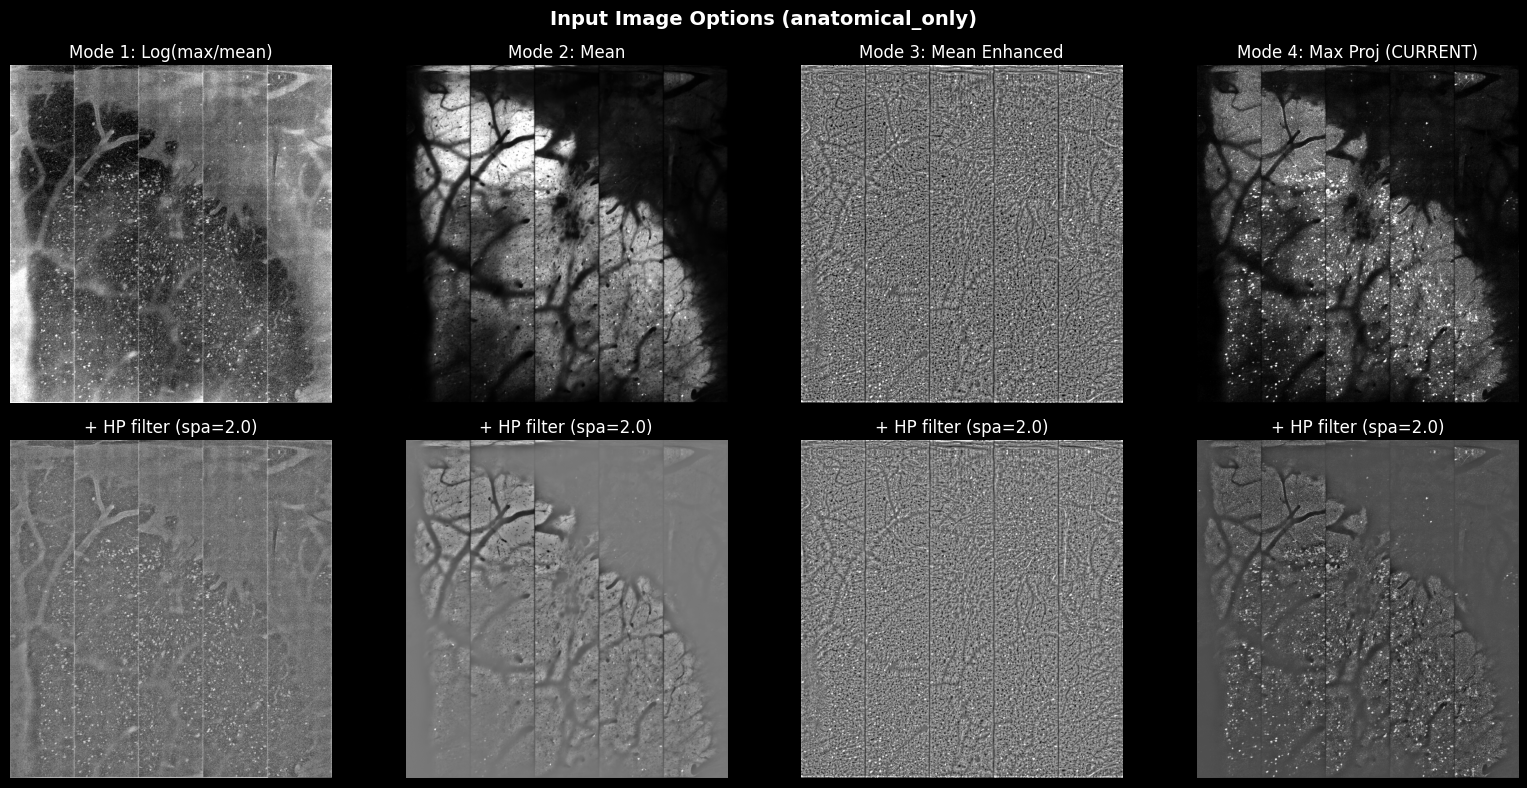

In [6]:
# Compare input image options
def get_anatomical_image(ops, mode):
    """Replicate Suite2p's image selection logic."""
    mean_img = ops['meanImg']
    max_proj = ops['max_proj']

    if mode == 1:
        # Log ratio
        img = np.log(np.maximum(1e-3, max_proj / np.maximum(1e-3, mean_img)))
    elif mode == 2:
        img = mean_img.copy()
    elif mode == 3:
        img = ops.get('meanImgE', mean_img).copy()
    elif mode == 4:
        img = max_proj.copy()
    else:
        img = mean_img.copy()

    return img

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for i, mode in enumerate([1, 2, 3, 4]):
    img = get_anatomical_image(ops, mode)
    img_norm = normalize99(img)

    marker = " (CURRENT)" if mode == ops.get('anatomical_only', 3) else ""
    mode_names = {1: 'Log(max/mean)', 2: 'Mean', 3: 'Mean Enhanced', 4: 'Max Proj'}

    axes[0, i].imshow(img_norm, cmap='gray', vmin=0, vmax=1)
    axes[0, i].set_title(f'Mode {mode}: {mode_names[mode]}{marker}')
    axes[0, i].axis('off')

    # With HP filter
    img_hp, _ = apply_hp_filter(img, DIAMETER, 2.0)  # Use spa=2.0 (best from grid search)
    axes[1, i].imshow(img_hp, cmap='gray')
    axes[1, i].set_title(f'+ HP filter (spa=2.0)')
    axes[1, i].axis('off')

plt.suptitle('Input Image Options (anatomical_only)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'anatomical_modes.png', dpi=150)
plt.show()

## Run Cellpose with Different Parameters

Let's systematically test different parameter combinations.

In [7]:
# Initialize Cellpose model
model = models.CellposeModel(gpu=core.use_gpu())

In [8]:
def run_cellpose_test(img, diameter, cellprob_threshold, flow_threshold, spatial_hp_cp):
    """Run Cellpose with specified parameters."""
    # Apply HP filter
    img_hp, _ = apply_hp_filter(img, diameter, spatial_hp_cp)

    # Run Cellpose
    t0 = time.perf_counter()
    masks, flows, _ = model.eval(
        img_hp,
        diameter=diameter,
        cellprob_threshold=cellprob_threshold,
        flow_threshold=flow_threshold
    )
    elapsed = time.perf_counter() - t0

    n_cells = masks.max()
    sizes = [np.sum(masks == i) for i in range(1, n_cells + 1)] if n_cells > 0 else []

    return {
        'masks': masks,
        'n_cells': n_cells,
        'sizes': np.array(sizes),
        'time': elapsed,
        'img_hp': img_hp
    }

In [9]:
# Test configurations
# Based on grid search: spa=2.0, cellprob=-6, flow=0.0 was best
configs = [
    # Current setting
    {'name': 'Current (spa=3.0)', 'spatial_hp_cp': 3.0, 'cellprob_threshold': -6.0, 'flow_threshold': 0.0},
    # Best from grid search
    {'name': 'Best (spa=2.0)', 'spatial_hp_cp': 2.0, 'cellprob_threshold': -6.0, 'flow_threshold': 0.0},
    # No HP filter
    {'name': 'No HP (spa=0)', 'spatial_hp_cp': 0, 'cellprob_threshold': -6.0, 'flow_threshold': 0.0},
    # Smaller HP
    {'name': 'Small HP (spa=0.5)', 'spatial_hp_cp': 0.5, 'cellprob_threshold': -6.0, 'flow_threshold': 0.0},
    # Conservative threshold
    {'name': 'Conserv. (cellprob=0)', 'spatial_hp_cp': 2.0, 'cellprob_threshold': 0.0, 'flow_threshold': 0.0},
    # Very conservative
    {'name': 'Very Conserv.', 'spatial_hp_cp': 2.0, 'cellprob_threshold': 0.5, 'flow_threshold': 0.4},
]

# Use max projection (anatomical_only=4) as the base image
base_img = max_proj

results = {}
for cfg in configs:
    print(f"Running: {cfg['name']}...", end=' ')
    result = run_cellpose_test(
        base_img,
        diameter=DIAMETER,
        cellprob_threshold=cfg['cellprob_threshold'],
        flow_threshold=cfg['flow_threshold'],
        spatial_hp_cp=cfg['spatial_hp_cp']
    )
    results[cfg['name']] = result
    print(f"{result['n_cells']} cells ({result['time']:.1f}s)")

Running: Current (spa=3.0)... 

Resizing is deprecated in v4.0.1+


969 cells (14.3s)
Running: Best (spa=2.0)... 

Resizing is deprecated in v4.0.1+


964 cells (13.9s)
Running: No HP (spa=0)... 

...

364 cells (13.9s)
Running: Conserv. (cellprob=0)... 

Resizing is deprecated in v4.0.1+


476 cells (14.0s)
Running: Very Conserv.... 

Resizing is deprecated in v4.0.1+


332 cells (14.1s)


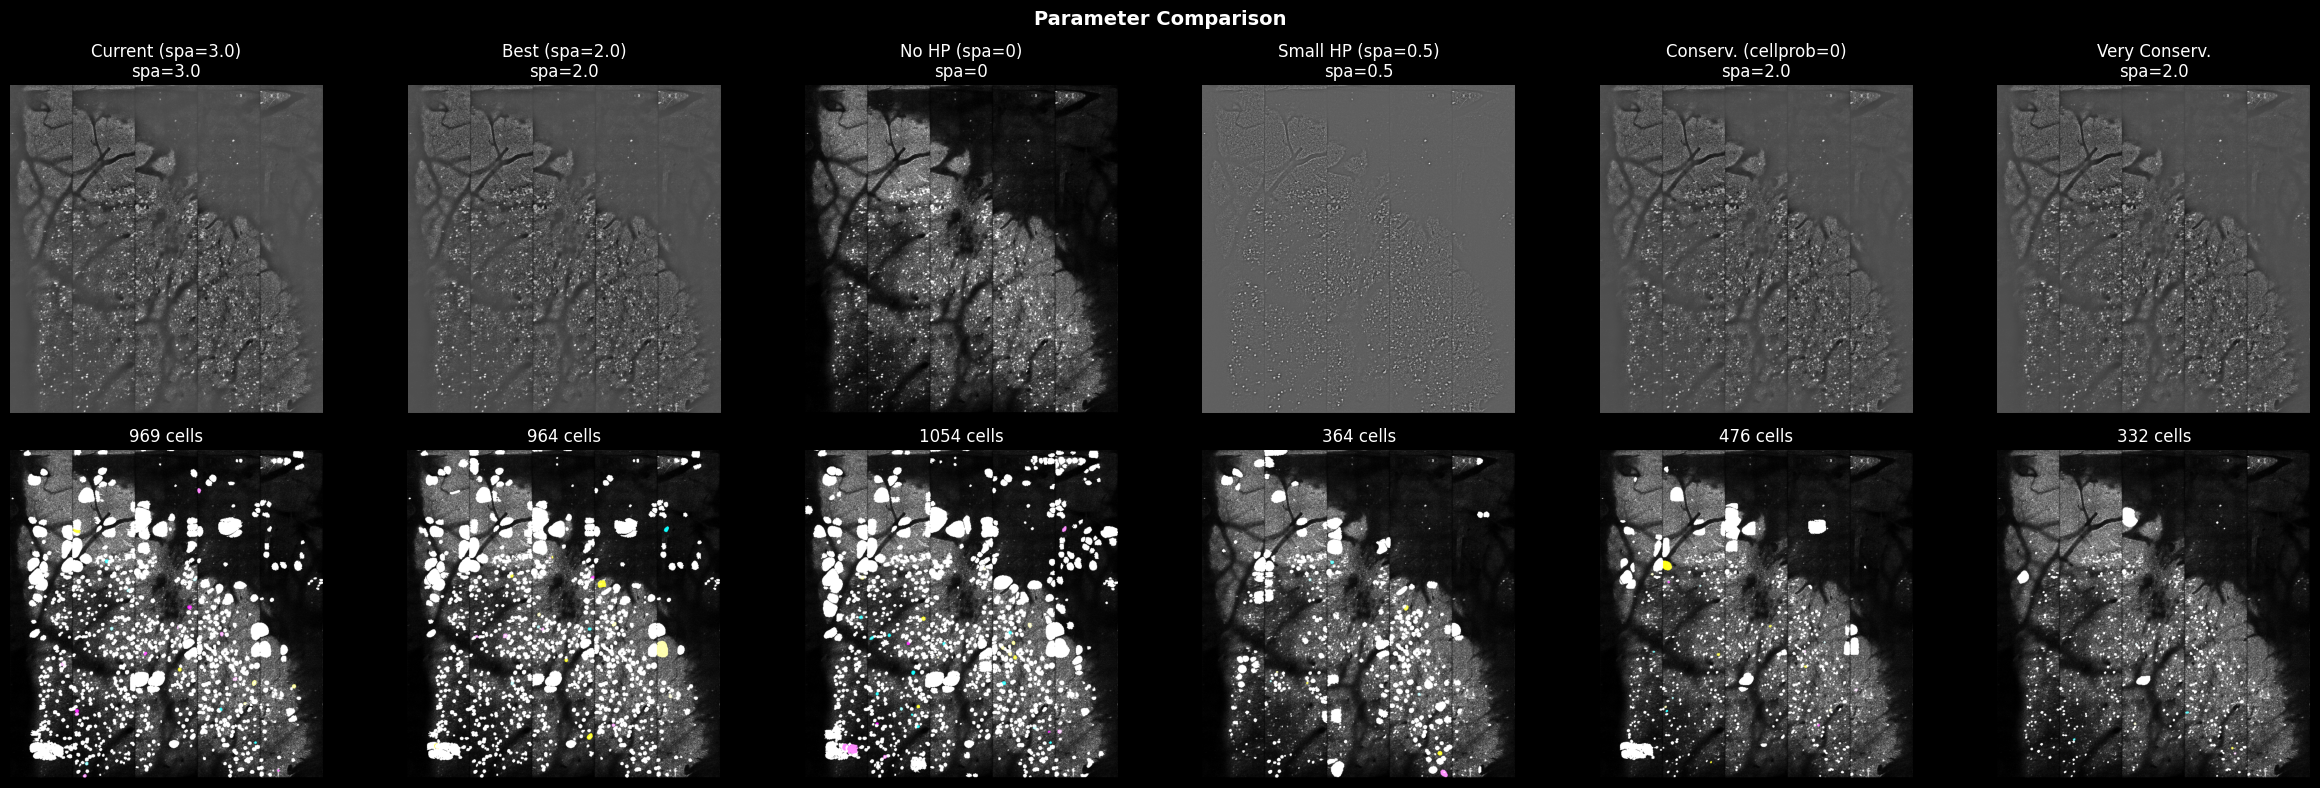

In [10]:
# Compare results visually
n_configs = len(configs)
fig, axes = plt.subplots(2, n_configs, figsize=(4*n_configs, 8))

for i, cfg in enumerate(configs):
    result = results[cfg['name']]

    # Top row: preprocessed image
    axes[0, i].imshow(result['img_hp'], cmap='gray')
    axes[0, i].set_title(f"{cfg['name']}\nspa={cfg['spatial_hp_cp']}")
    axes[0, i].axis('off')

    # Bottom row: detection overlay
    axes[1, i].imshow(mask_overlay(base_img, result['masks']))
    axes[1, i].set_title(f"{result['n_cells']} cells")
    axes[1, i].axis('off')

plt.suptitle('Parameter Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'parameter_comparison.png', dpi=150)
plt.show()

In [11]:
# Summary table
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)
print(f"{'Configuration':<25} {'Cells':>8} {'Med Size':>10} {'Max Size':>10}")
print("-"*55)

for cfg in configs:
    r = results[cfg['name']]
    med_size = np.median(r['sizes']) if len(r['sizes']) > 0 else 0
    max_size = np.max(r['sizes']) if len(r['sizes']) > 0 else 0
    print(f"{cfg['name']:<25} {r['n_cells']:>8} {med_size:>10.0f} {max_size:>10.0f}")


RESULTS SUMMARY
Configuration                Cells   Med Size   Max Size
-------------------------------------------------------
Current (spa=3.0)              969         58       1256
Best (spa=2.0)                 964         58       1460
No HP (spa=0)                 1054         59       1767
Small HP (spa=0.5)             364         61       1095
Conserv. (cellprob=0)          476         29       1342
Very Conserv.                  332         25       1271


## Test Different Input Images

In [12]:
# Test with different base images using best HP setting (spa=2.0)
image_configs = [
    ('Mean', mean_img),
    ('Mean Enhanced', mean_img_e),
    ('Max Projection', max_proj),
    ('Vcorr', vcorr),
]

image_results = {}
for name, img in image_configs:
    print(f"Running with {name}...", end=' ')
    result = run_cellpose_test(
        img,
        diameter=DIAMETER,
        cellprob_threshold=-6.0,
        flow_threshold=0.0,
        spatial_hp_cp=2.0  # Best from grid search
    )
    image_results[name] = result
    print(f"{result['n_cells']} cells")

Running with Mean... 

Resizing is deprecated in v4.0.1+


525 cells
Running with Mean Enhanced... 

Resizing is deprecated in v4.0.1+


293 cells
Running with Max Projection... 

Resizing is deprecated in v4.0.1+


964 cells
Running with Vcorr... 

Resizing is deprecated in v4.0.1+


139 cells


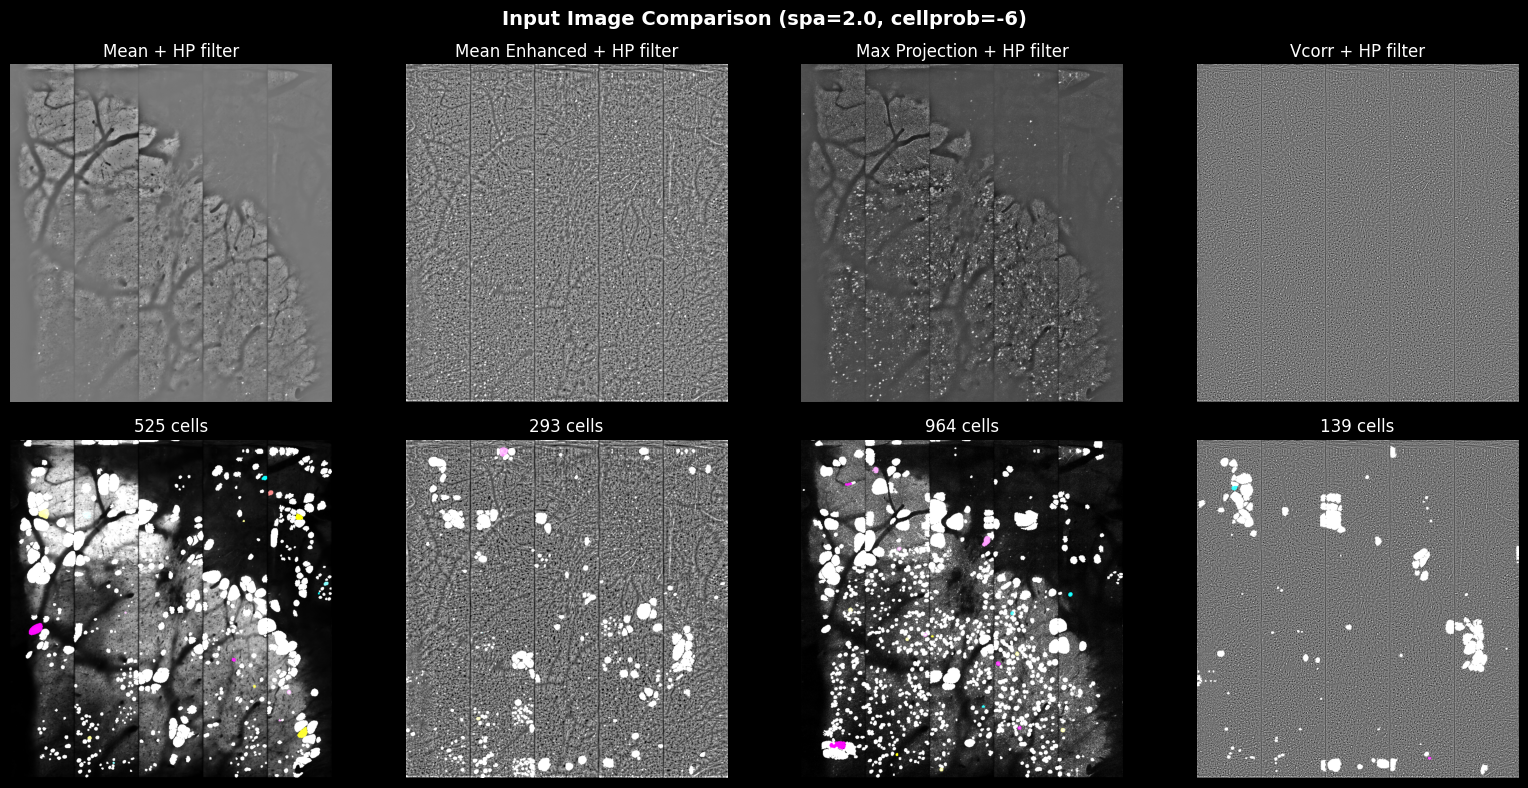

In [13]:
# Visualize
fig, axes = plt.subplots(2, len(image_configs), figsize=(4*len(image_configs), 8))

for i, (name, img) in enumerate(image_configs):
    result = image_results[name]

    axes[0, i].imshow(result['img_hp'], cmap='gray')
    axes[0, i].set_title(f'{name} + HP filter')
    axes[0, i].axis('off')

    axes[1, i].imshow(mask_overlay(img, result['masks']))
    axes[1, i].set_title(f"{result['n_cells']} cells")
    axes[1, i].axis('off')

plt.suptitle('Input Image Comparison (spa=2.0, cellprob=-6)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'input_image_comparison.png', dpi=150)
plt.show()

## Test Different Diameters

In [14]:
# Test different diameters
diameters = [4, 6, 8, 10, 12]

diameter_results = {}
for dia in diameters:
    print(f"Testing diameter={dia}...", end=' ')
    result = run_cellpose_test(
        max_proj,
        diameter=dia,
        cellprob_threshold=-6.0,
        flow_threshold=0.0,
        spatial_hp_cp=2.0
    )
    diameter_results[dia] = result
    print(f"{result['n_cells']} cells")

Testing diameter=4... 

Resizing is deprecated in v4.0.1+


794 cells
Testing diameter=6... 

Resizing is deprecated in v4.0.1+


964 cells
Testing diameter=8... 

...

1018 cells
Testing diameter=10... 

Resizing is deprecated in v4.0.1+


1168 cells
Testing diameter=12... 

Resizing is deprecated in v4.0.1+


1131 cells


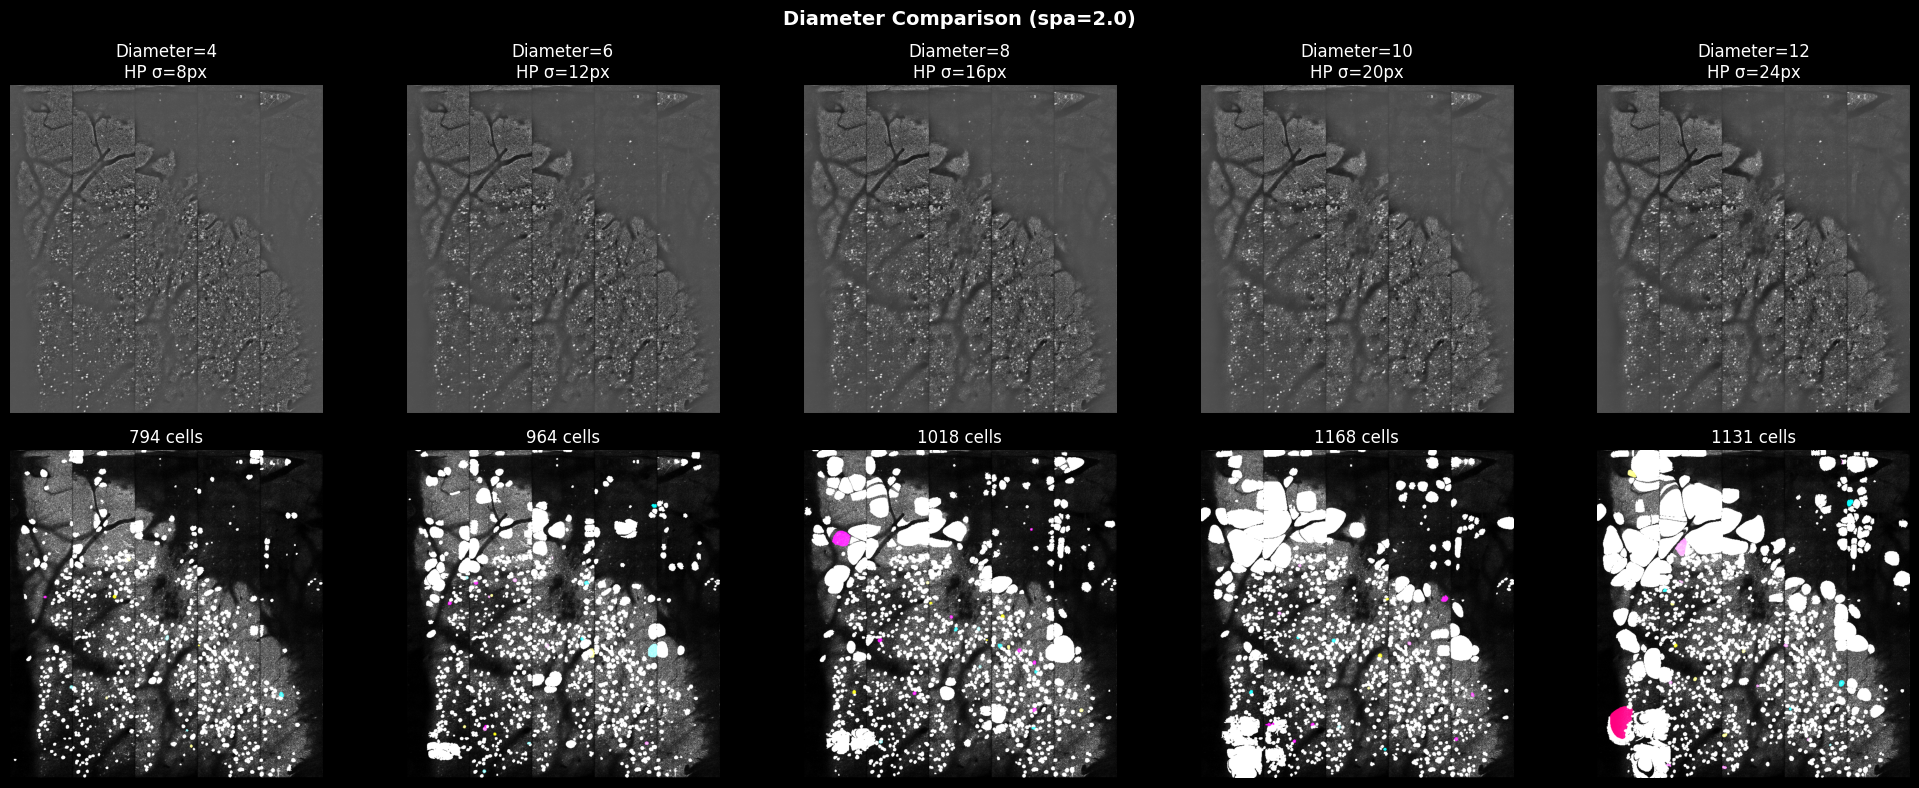

In [15]:
# Plot diameter comparison
fig, axes = plt.subplots(2, len(diameters), figsize=(4*len(diameters), 8))

for i, dia in enumerate(diameters):
    result = diameter_results[dia]

    axes[0, i].imshow(result['img_hp'], cmap='gray')
    axes[0, i].set_title(f'Diameter={dia}\nHP σ={dia*2}px')
    axes[0, i].axis('off')

    axes[1, i].imshow(mask_overlay(max_proj, result['masks']))
    axes[1, i].set_title(f"{result['n_cells']} cells")
    axes[1, i].axis('off')

plt.suptitle('Diameter Comparison (spa=2.0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diameter_comparison.png', dpi=150)
plt.show()

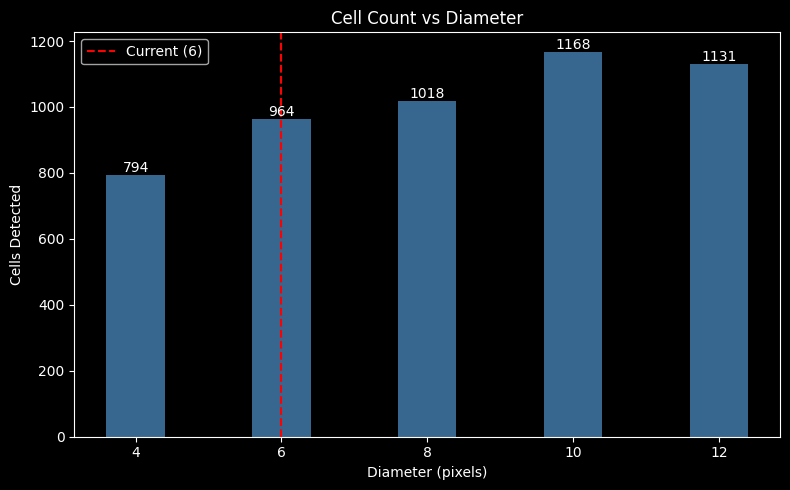

In [16]:
# Cell count vs diameter
fig, ax = plt.subplots(figsize=(8, 5))

counts = [diameter_results[d]['n_cells'] for d in diameters]
ax.bar(diameters, counts, color='steelblue', alpha=0.8)
ax.set_xlabel('Diameter (pixels)')
ax.set_ylabel('Cells Detected')
ax.set_title('Cell Count vs Diameter')
ax.axvline(DIAMETER, color='red', linestyle='--', label=f'Current ({DIAMETER})')
ax.legend()

for d, c in zip(diameters, counts):
    ax.annotate(str(c), (d, c), ha='center', va='bottom')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'diameter_vs_cells.png', dpi=150)
plt.show()

## Zoomed 

In [17]:
# Zoom into a region to see detail
# Find region with cells
best_result = results['Best (spa=2.0)']
best_mask = best_result['masks']

# Find center of mass of detected cells
if best_mask.max() > 0:
    y_coords, x_coords = np.where(best_mask > 0)
    cy, cx = int(np.median(y_coords)), int(np.median(x_coords))
else:
    cy, cx = mean_img.shape[0] // 2, mean_img.shape[1] // 2

# Zoom window
zoom_size = 150
y1, y2 = max(0, cy - zoom_size), min(mean_img.shape[0], cy + zoom_size)
x1, x2 = max(0, cx - zoom_size), min(mean_img.shape[1], cx + zoom_size)

print(f"Zooming to region: y=[{y1}:{y2}], x=[{x1}:{x2}]")

Zooming to region: y=[257:557], x=[157:457]


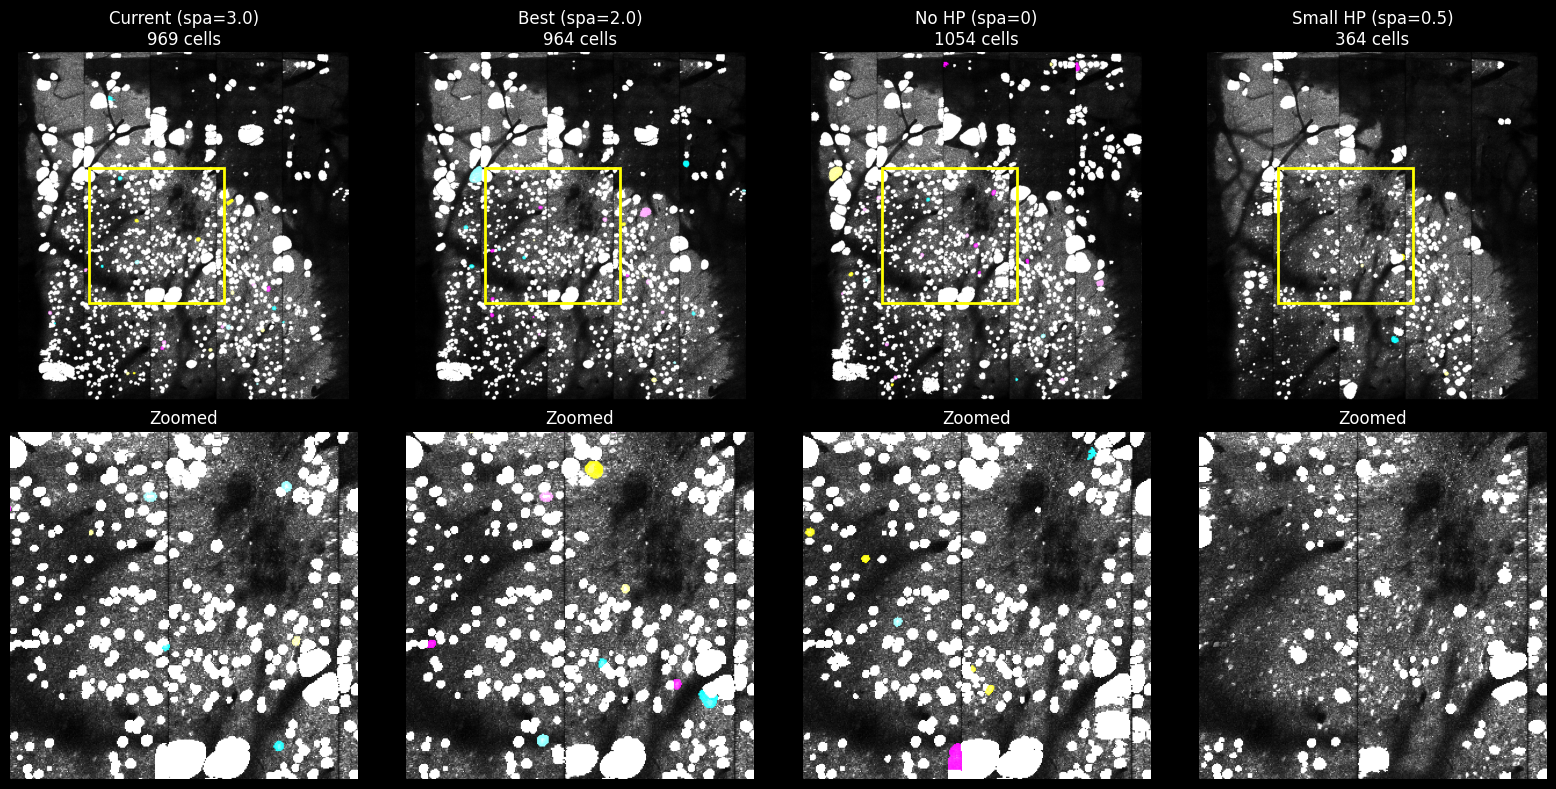

In [18]:
# Zoomed comparison
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

configs_to_show = ['Current (spa=3.0)', 'Best (spa=2.0)', 'No HP (spa=0)', 'Small HP (spa=0.5)']

for i, name in enumerate(configs_to_show):
    result = results[name]

    # Full image
    axes[0, i].imshow(mask_overlay(max_proj, result['masks']))
    axes[0, i].add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
                                        fill=False, edgecolor='yellow', linewidth=2))
    axes[0, i].set_title(f"{name}\n{result['n_cells']} cells")
    axes[0, i].axis('off')

    # Zoomed
    axes[1, i].imshow(mask_overlay(max_proj, result['masks'])[y1:y2, x1:x2])
    axes[1, i].set_title('Zoomed')
    axes[1, i].axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'zoomed_comparison.png', dpi=150)
plt.show()

## Cell Size Distribution

C:\Users\RBO\AppData\Local\Temp\ipykernel_105264\2154560874.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[l.split('(')[0].strip() for l in labels])


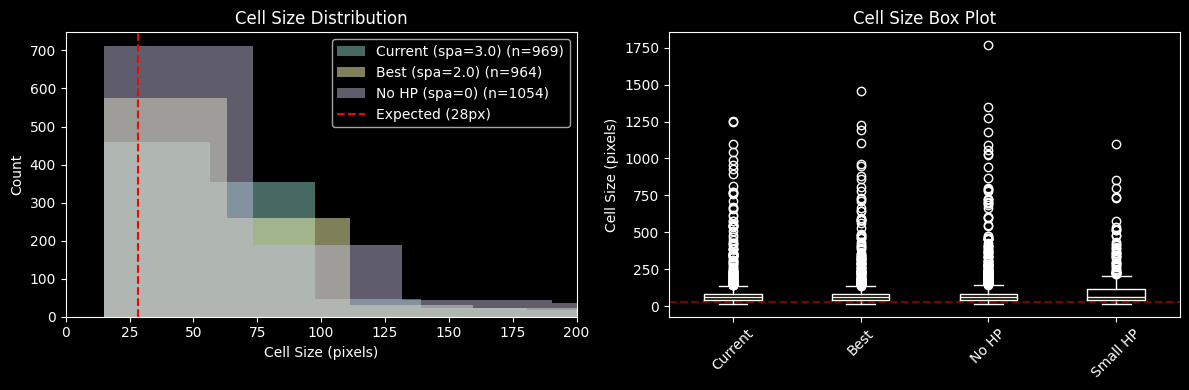

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Expected cell area
expected_area = np.pi * (DIAMETER / 2) ** 2

# Histogram
ax = axes[0]
for name in ['Current (spa=3.0)', 'Best (spa=2.0)', 'No HP (spa=0)']:
    sizes = results[name]['sizes']
    if len(sizes) > 0:
        ax.hist(sizes, bins=30, alpha=0.5, label=f"{name} (n={len(sizes)})")

ax.axvline(expected_area, color='red', linestyle='--', label=f'Expected ({expected_area:.0f}px)')
ax.set_xlabel('Cell Size (pixels)')
ax.set_ylabel('Count')
ax.set_title('Cell Size Distribution')
ax.legend()
ax.set_xlim(0, 200)

# Box plot
ax = axes[1]
data = [results[name]['sizes'] for name in configs_to_show if len(results[name]['sizes']) > 0]
labels = [name for name in configs_to_show if len(results[name]['sizes']) > 0]
if data:
    ax.boxplot(data, labels=[l.split('(')[0].strip() for l in labels])
ax.axhline(expected_area, color='red', linestyle='--', alpha=0.5)
ax.set_ylabel('Cell Size (pixels)')
ax.set_title('Cell Size Box Plot')
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'size_distribution.png', dpi=150)
plt.show()

## Summary

**`spatial_hp_cp=3.0`**:

1. This creates a Gaussian HP filter with σ = diameter × 3.0 = 18 pixels
2. This is 3× the expected cell size, so the filter removes cell-scale contrast
3. Cells become invisible to Cellpose after this